# CHICAGO CAR CRASH PREDICTION AND ANALYSIS

# BUSINESS UNDERSTANDING

## PROBLEM STATEMENT
Traffic accidents are a mojor concern in Chicago. Understanding the conditions that lead to severe crashes will help the Vehicle safety board.
This project aims to build a classification model that predicts whether a car crash will result in injuries based on environmental factors or other factors. The insights from this model will help identify high risk conditions and implement preventive measures to imrove road safety.

## Stakeholders
- Vehicle safety board
   - Responsible for road safety
   - Implement safety programs
   - They will use this model to identify high risk driving conditions and issue weather related alerts 
- City of Chicago


## Key Questions
1. What factors contribute to most crashes?
2. Under what conditions are crashes most likely to result in injuries?
3. Can we predict whether a crash will result in injuries based on environmental conditions?
4. Can we predict the primary contributory cause of accidents?



# DATA UNDERSTANDING

The dataset we are using has been obtained from kaggle, it contains car crashes in chicago from 2019 to 2022. Its particulary useful because it includes car crash variables and environmental factors that influence crash outcomes. It allows us to analyze patterns in traffic accidents.

#### Importing libraries

In [116]:
# Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning models and evaluation matrix
#Training and testing split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Regression builders
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
 
 

#### Loading the dataset

In [73]:
df=pd.read_csv("chicago_2019_2022.csv")

C:\Users\Dell\AppData\Local\Temp\ipykernel_15680\2883874868.py:1: DtypeWarning: Columns (53) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("chicago_2019_2022.csv")


#### Loads the dataset into pandas dataframe so that we can explore and manipulate it

#### Data inspection

In [74]:
df.head()

,id,crash_date,crash_time,town,city,state,country,total_injured,total_killed,injury_incapacitated,...,windgust,windspeed,winddir,pressure,visibility,cloudcover,conditions,sunrise,sunset,moonphase
0,200319661,07/18/19,10:35,harwood heights,chicago,illinois,usa,0,0,0,...,\N,6.9,193.0,1013.9,1.8,54.6,"Rain, Partially cloudy",5:31:20,20:23:09,0.56
1,200320852,07/21/19,13:45,englewood,chicago,illinois,usa,0,0,0,...,\N,11.4,3.0,1013.3,7.4,87.4,"Rain, Partially cloudy",5:33:58,20:19:28,0.66
2,200320894,07/21/19,16:00,cragin,chicago,illinois,usa,0,0,0,...,\N,13.7,17.0,1013.6,9.9,58.2,"Rain, Partially cloudy",5:33:54,20:20:12,0.66
3,200320909,07/21/19,16:45,cragin,chicago,illinois,usa,0,0,0,...,\N,13.7,17.0,1013.6,9.9,58.3,"Rain, Partially cloudy",5:33:53,20:20:10,0.66
4,200320967,07/21/19,23:05,cicero,chicago,illinois,usa,0,0,0,...,\N,4.9,342.0,1018.4,9.9,0.0,Clear,5:34:53,20:19:06,0.69


In [75]:
df.shape

(372062, 65)

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372062 entries, 0 to 372061
Data columns (total 65 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   id                                372062 non-null  int64  
 1   crash_date                        372062 non-null  object 
 2   crash_time                        372062 non-null  object 
 3   town                              372062 non-null  object 
 4   city                              372062 non-null  object 
 5   state                             372062 non-null  object 
 6   country                           372062 non-null  object 
 7   total_injured                     372062 non-null  object 
 8   total_killed                      372062 non-null  object 
 9   injury_incapacitated              372062 non-null  object 
 10  injury_non_incapacitated          372062 non-null  object 
 11  most_severe_injury                372062 non-null  o

#### These commands help us understand the dataset. 
 - .head()- returns the first 5 rows to inspect columns
- .shape- shows the total number of rows and columns
- .info()- shows the column names , data tyoes and missing values

#### Box plot to check outliers

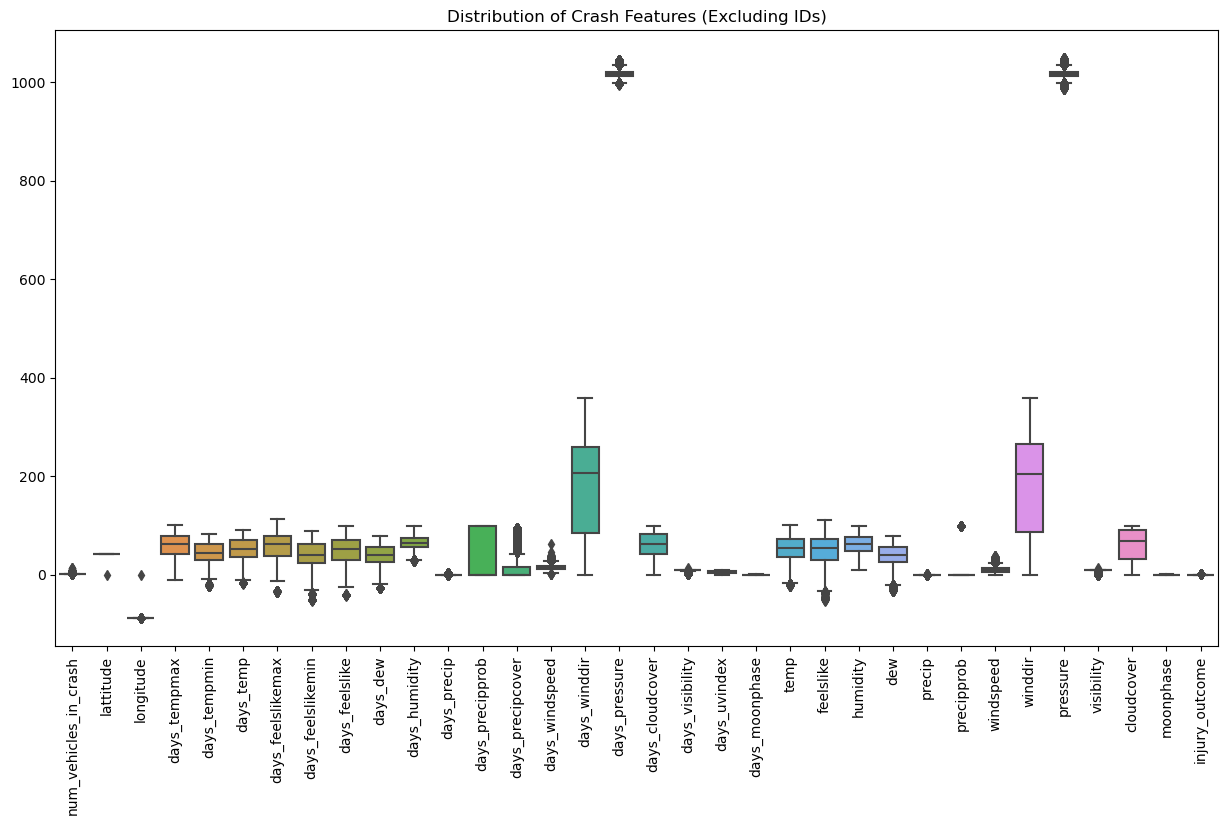

In [121]:

# Create a list of columns to exclude (anything with huge numbers like IDs)
# We also exclude 'total_injured' since it was your "leakage" column
exclude_cols = ['id', 'total_injured', 'total_killed']

# Filter the dataframe
df_to_plot = df.select_dtypes(include=['number']).drop(columns=exclude_cols, errors='ignore')

plt.figure(figsize=(15, 8))
sns.boxplot(data=df_to_plot)
plt.xticks(rotation=90) # This makes the labels readable
plt.title("Distribution of Crash Features (Excluding IDs)")
plt.show()

# First get to know where to put this code first so that the flow makes sense

#### Defining the target variable

#### Mapping to deal convert string to numerics

In [77]:
# Map the knowns, then force anything leftover (the NaNs) to be 0
mapping = {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, 
    '6': 6, '7': 7, '8': 8, '9': 9, '10': 10, '11': 11, 
    '12': 12, '13': 13, '15': 15, '16': 16, '19': 19, 
    '21': 21, '\\N': 0}
df["total_injured"] = df["total_injured"].map(mapping).fillna(0)

In [78]:
print(df["total_injured"].dtype)

int64


In [79]:
df["total_injured"].isna()

0         False
1         False
2         False
3         False
4         False
          ...  
372057    False
372058    False
372059    False
372060    False
372061    False
Name: total_injured, Length: 372062, dtype: bool

##### We have used the mapping function to convert strings to text and filled the missing values with 0 instead of coercing or one-hot encoding, we have then confired the data type after mapping and eventually checked for missing values. Next we define our target

In [80]:
# Feature engineering- this code creates the injury_outcome column
# It creates a binary classification target, checks whether the crash caused an injury or not
df["injury_outcome"]= np.where(df["total_injured"] > 0, 1, 0)

In [81]:
# Confirming our target  variable has been created
df.columns

Index(['id', 'crash_date', 'crash_time', 'town', 'city', 'state', 'country',
       'total_injured', 'total_killed', 'injury_incapacitated',
       'injury_non_incapacitated', 'most_severe_injury', 'crash_type',
       'contributory_cause', 'sec_contributory_cause', 'num_vehicles_in_crash',
       'crash_hit_and_run', 'crash_severity', 'traffic_control_device',
       'traffic_control_device_condition', 'road_defect', 'lattitude',
       'longitude', 'days_tempmax', 'days_tempmin', 'days_temp',
       'days_feelslikemax', 'days_feelslikemin', 'days_feelslike', 'days_dew',
       'days_humidity', 'days_precip', 'days_precipprob', 'days_precipcover',
       'days_preciptype', 'days_snow', 'days_snowdepth', 'days_windgust',
       'days_windspeed', 'days_winddir', 'days_pressure', 'days_cloudcover',
       'days_visibility', 'days_uvindex', 'days_conditions', 'days_moonphase',
       'temp', 'feelslike', 'humidity', 'dew', 'precip', 'precipprob', 'snow',
       'snowdepth', 'precip_type',

##### We have defined our target by created a binary classification target 

#### Train_test split

In [82]:
# We split the dataset
target=X
feature=y
X=df.drop("injury_outcome", axis=1)
y=df["injury_outcome"]
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42)
print(target, X.shape)
print(feature, y.shape)

        num_vehicles_in_crash  days_feelslike  days_temp  lattitude  \
0                           3            82.8       79.2  41.998354   
1                           2            74.3       74.3  41.765266   
2                           2            73.8       73.8  41.902855   
3                           2            73.9       73.9  41.899822   
4                           2            70.8       70.8  41.844581   
...                       ...             ...        ...        ...   
372057                      2            84.4       81.3  41.855432   
372058                      2            83.7       81.2  41.888306   
372059                      2            83.5       81.0  41.926161   
372060                      2            83.6       79.4  41.759166   
372061                      2            83.2       79.5  41.992609   

        days_uvindex  total_injured  visibility  windspeed  
0                  1              0         1.8        6.9  
1                  4     

##### We split the dataset into training data and testing data 80% and 20% respectively . This prevents the model from seeing the test data during training

#### Plotting a heatmap

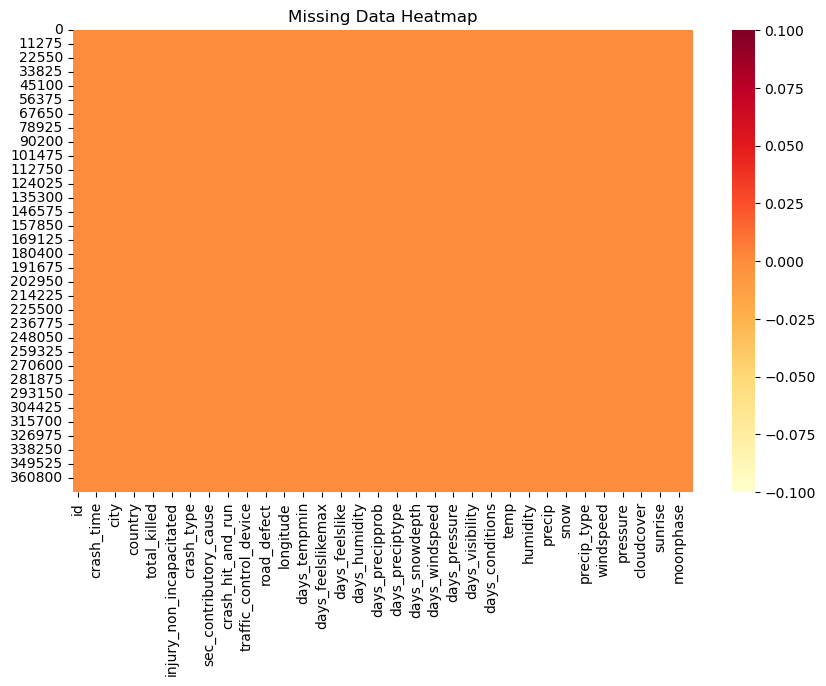

In [83]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cmap="YlOrRd")
plt.title("Missing Data Heatmap")
plt.show()

#### Feature Selection
We select the relevant features

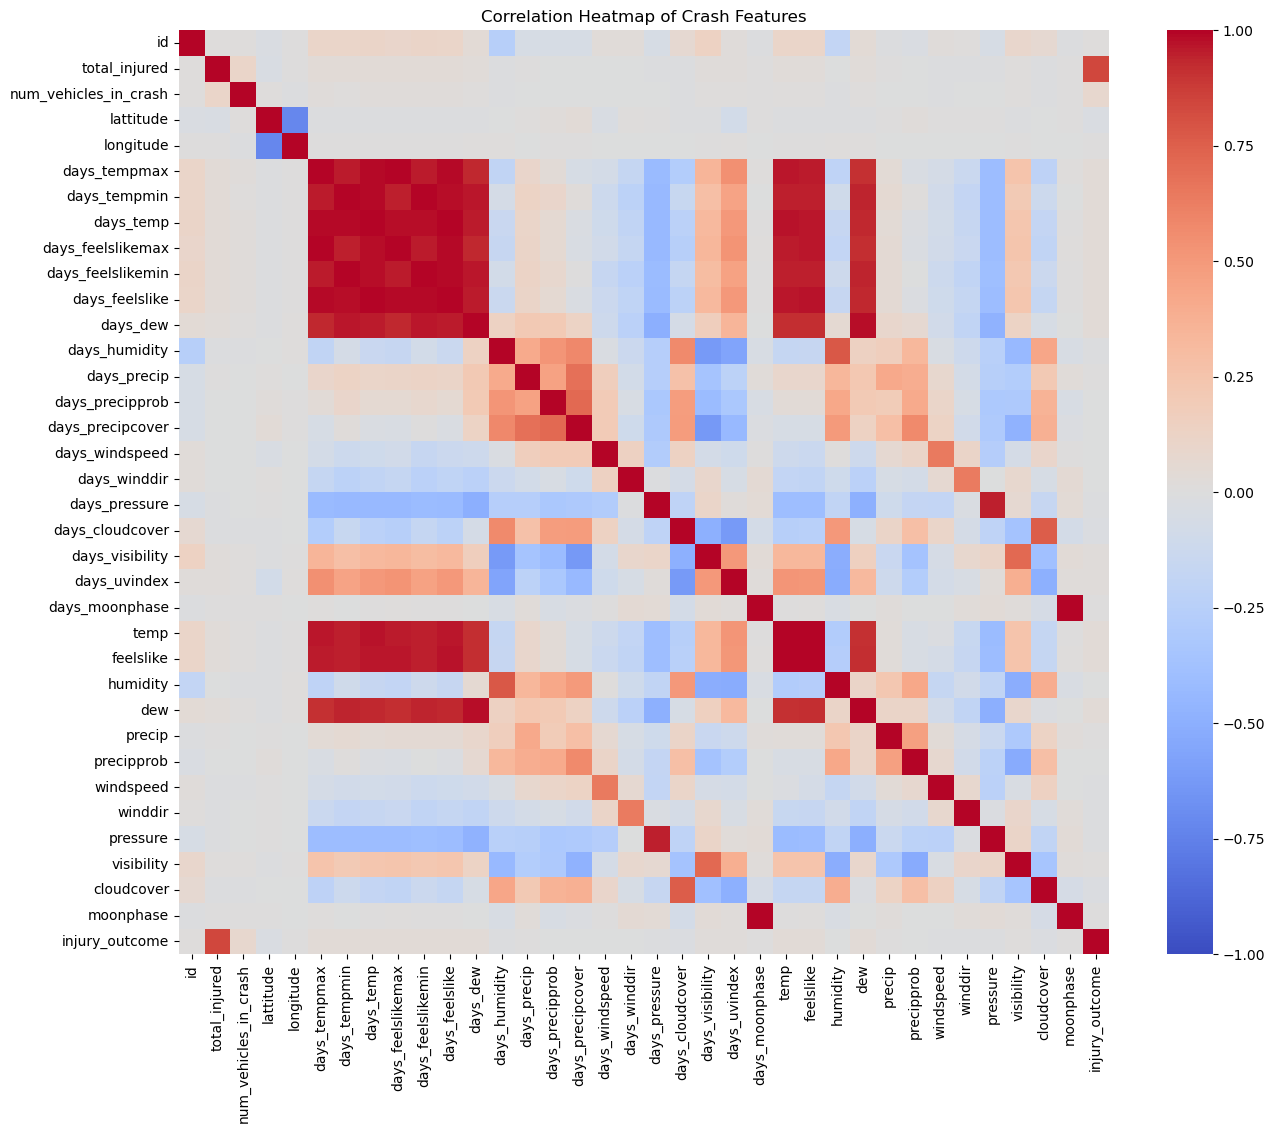

In [ ]:
# 1. Calculate the correlation matrix
# 'numeric_only=True' ensures we don't try to calculate correlation on text columns
corr_matrix = df.corr(numeric_only=True)

# 2. Set up the figure size so it's readable
plt.figure(figsize=(15, 12))

# 3. Create the heatmap
# annot=False keeps it clean; 'coolwarm' shows negative (blue) and positive (red) correlations
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)

plt.title("Correlation Heatmap of Crash Features")
plt.show()

In [85]:
# Calculate correlation, take the absolute value, and sort
correlations = df.corr(numeric_only=True)['injury_outcome'].abs().sort_values(ascending=False)

# Display the top 15 predictors
print(correlations.head(15))

injury_outcome           1.000000
total_injured            0.840397
num_vehicles_in_crash    0.085254
days_feelslike           0.038048
days_temp                0.037896
days_tempmax             0.037724
days_feelslikemin        0.037601
days_feelslikemax        0.037505
days_tempmin             0.037114
days_dew                 0.034637
feelslike                0.034412
temp                     0.033851
dew                      0.033716
lattitude                0.025175
days_uvindex             0.022983
Name: injury_outcome, dtype: float64


#### We are using these relevant columns helps reduce noise and improve model performance

In [86]:
# This lists every column and its data type
print(X_train.dtypes)

id              int64
crash_date     object
crash_time     object
town           object
city           object
               ...   
cloudcover    float64
conditions     object
sunrise        object
sunset         object
moonphase     float64
Length: 65, dtype: object


In [87]:
# 1. Convert to datetime
df['crash_date'] = pd.to_datetime(df['crash_date'])

# 2. Extract the names of the days (e.g., 'Monday', 'Tuesday')
df['day_name'] = df['crash_date'].dt.day_name()

# 3. One-Hot Encode the day names
# This creates columns like 'day_name_Monday', 'day_name_Tuesday', etc.
df = pd.get_dummies(df, columns=['day_name'], prefix='day')

# 4. Drop the original date column so the scaler doesn't crash
df = df.drop(columns=['crash_date'])

C:\Users\Dell\AppData\Local\Temp\ipykernel_15680\3226894198.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['crash_date'] = pd.to_datetime(df['crash_date'])


In [88]:
print(df.columns.tolist())

['id', 'crash_time', 'town', 'city', 'state', 'country', 'total_injured', 'total_killed', 'injury_incapacitated', 'injury_non_incapacitated', 'most_severe_injury', 'crash_type', 'contributory_cause', 'sec_contributory_cause', 'num_vehicles_in_crash', 'crash_hit_and_run', 'crash_severity', 'traffic_control_device', 'traffic_control_device_condition', 'road_defect', 'lattitude', 'longitude', 'days_tempmax', 'days_tempmin', 'days_temp', 'days_feelslikemax', 'days_feelslikemin', 'days_feelslike', 'days_dew', 'days_humidity', 'days_precip', 'days_precipprob', 'days_precipcover', 'days_preciptype', 'days_snow', 'days_snowdepth', 'days_windgust', 'days_windspeed', 'days_winddir', 'days_pressure', 'days_cloudcover', 'days_visibility', 'days_uvindex', 'days_conditions', 'days_moonphase', 'temp', 'feelslike', 'humidity', 'dew', 'precip', 'precipprob', 'snow', 'snowdepth', 'precip_type', 'windgust', 'windspeed', 'winddir', 'pressure', 'visibility', 'cloudcover', 'conditions', 'sunrise', 'sunset',

In [89]:
# This will show you exactly which columns have text instead of numbers
print(X_train.select_dtypes(include=['object', 'datetime']).columns.tolist())

['crash_date', 'crash_time', 'town', 'city', 'state', 'country', 'total_killed', 'injury_incapacitated', 'injury_non_incapacitated', 'most_severe_injury', 'crash_type', 'contributory_cause', 'sec_contributory_cause', 'crash_hit_and_run', 'crash_severity', 'traffic_control_device', 'traffic_control_device_condition', 'road_defect', 'days_preciptype', 'days_snow', 'days_snowdepth', 'days_windgust', 'days_conditions', 'snow', 'snowdepth', 'precip_type', 'windgust', 'conditions', 'sunrise', 'sunset']


### Feature Scaling

#### This is to partition my dataframe instead dropping columns 

In [90]:
# 1. Create a "lean" version for the model
# This contains ONLY the numeric columns we want to use
model_features = [
    'num_vehicles_in_crash', 'days_feelslike', 'days_temp', 
    'lattitude', 'days_uvindex', 'cloudcover', 'visibility', 'windspeed'
]

# Create the subset specifically for the model
X = df[model_features]
y = df['injury_outcome']

# Now, 'df' still has your cities, dates, and names, but 'X' is clean for the model

In [101]:
X_train = X_train[model_features]
X_test = X_test[model_features]

scaler= StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

Scaling standardizes the data so all features are on the same scale
- - Scaler fit only on training data
- - test daya only transformed

#### Baseline Model- Logistic regression

In [102]:
log_model = LogisticRegression(max_iter=10000)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=10000)

#### Predictions

In [103]:
y_pred_log = log_model.predict(X_test_scaled)
print(y_pred_log)

[0 0 0 ... 0 0 0]


#### Uses the trained model to predict the outcomes for the test data

#### Model Evaluation
Accuracy

In [104]:
accuracy_score(y_test, y_pred_log)

0.8532917635359413

#### Accuracy measures the proportion of the correct predictions

#### Confusion matrix

In [105]:
confusion_matrix(y_test, y_pred_log)

array([[63466,    31],
       [10886,    30]], dtype=int64)

#### Shows prediction outcomes

#### Second model-decision tree

In [106]:
tree_model = DecisionTreeClassifier(max_depth=5)

tree_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5)

#### Predictions

In [107]:
y_pred_tree = tree_model.predict(X_test)
print(y_pred_tree)

[0 0 0 ... 0 0 0]


#### Evaluate tree model

In [108]:
accuracy_score(y_test, y_pred_tree)

print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.85      1.00      0.92     63497
           1       0.38      0.00      0.00     10916

    accuracy                           0.85     74413
   macro avg       0.62      0.50      0.46     74413
weighted avg       0.78      0.85      0.79     74413



#### Compare then models

In [109]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))

Logistic Regression Accuracy: 0.8532917635359413
Decision Tree Accuracy: 0.8532111324634136


##### Helps determine which model performs better

## What we have not done
- - Ridge
- - Lasso
- - features Box plot
- - features hist plot
- - pair plot
- - made a good conclusion and recommendation
- - missing powerpoint
- - no commit pushes from split 
- - missing readme
- - missing requirements.txt
- - roc and auc
